# CISC 886 -- Fine-Tuning: Qwen2.5-1.5B on StackOverflow Python Q&A
**NetID:** 25jdvr | **Course:** CISC 886 -- Queen's University

| Field | Value |
|---|---|
| **Model** | Qwen/Qwen2.5-1.5B-Instruct |
| **Technique** | QLoRA (4-bit) via Unsloth |
| **Runtime** | Docker -- unsloth/unsloth image (GPU required) |
| **Dataset** | StackOverflow Python Q&A -- quality filtered |
| **Training** | 200 steps (quick validation run) |

> **Docker image:** `docker pull unsloth/unsloth`
> **Run command:**
> ```bash
> docker run --gpus all -it -p 8888:8888 \
>   -v ~/fine-tuning:/workspace \
>   unsloth/unsloth \
>   jupyter notebook --ip=0.0.0.0 --no-browser --allow-root
> ```
> All packages (Unsloth, PyTorch, CUDA) are pre-installed in the image.
> **Do NOT run the install cell** -- skip straight to Section 2.


---
## Section 0 -- Configuration
**Only edit this cell.** Everything else reads from these variables.


In [ ]:
# everything the notebook needs is set here -- change values in this cell only

S3_BUCKET       = "25jdvr-chatbot-bucket"
S3_TRAIN_PATH   = f"s3://{S3_BUCKET}/processed/train/"
S3_VAL_PATH     = f"s3://{S3_BUCKET}/processed/val/"
S3_MODEL_OUTPUT = f"s3://{S3_BUCKET}/model/finetuned-qwen/"

BASE_MODEL      = "unsloth/Qwen2.5-1.5B-Instruct"

# Docker paths -- the container mounts your host folder at /workspace
LOCAL_DATA_DIR  = "/workspace/data"
LOCAL_MODEL_DIR = "/workspace/finetuned-model"
LOCAL_GGUF_DIR  = "/workspace/gguf-model"

# LoRA -- rank 16 is a good middle ground for a 1.5B model
LORA_RANK    = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

# Training numbers -- tuned for GPU inside Docker container
MAX_SEQ_LENGTH  = 512
BATCH_SIZE      = 2
GRAD_ACCUM      = 16     # effective batch = 32
LEARNING_RATE   = 2e-4
NUM_EPOCHS      = 1
WARMUP_RATIO    = 0.05
WEIGHT_DECAY    = 0.01
MAX_TRAIN_ROWS  = 50_000
MAX_VAL_ROWS    = 1_000
MAX_STEPS       = 200    # 200 steps for a quick validation run
RANDOM_SEED     = 42

# quality filters -- avoids rerunning EMR
MIN_ANSWER_LEN   = 300
MIN_ANSWER_SCORE = 3
LOG_STEPS        = 25
SAVE_STEPS       = 500

SYSTEM_PROMPT = (
    "You are a helpful Python programming assistant. "
    "Provide clear, accurate answers with working code examples."
)

print("Config loaded:")
print(f"  Base model      : {BASE_MODEL}")
print(f"  Train data      : {S3_TRAIN_PATH}")
print(f"  Max train rows  : {MAX_TRAIN_ROWS:,}")
print(f"  LoRA rank/alpha : {LORA_RANK}/{LORA_ALPHA}")
print(f"  Epochs          : {NUM_EPOCHS}")
print(f"  Max steps       : {MAX_STEPS}")
print(f"  Min answer len  : {MIN_ANSWER_LEN} chars")
print(f"  Min answer score: {MIN_ANSWER_SCORE} upvotes")
print(f"  Effective batch : {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}")
print(f"  Max seq length  : {MAX_SEQ_LENGTH} tokens")
print(f"  Local output    : {LOCAL_MODEL_DIR}")


? Config loaded
   Base model      : unsloth/Qwen2.5-1.5B-Instruct
   Train data      : s3://25jdvr-chatbot-bucket/processed/train/
   Max train rows  : 50,000
   LoRA rank/alpha : 16/32
   Epochs          : 1
   Max steps       : 200 (1 full epoch)
   Min answer len  : 300 chars (quality filter)
   Min answer score: 3 upvotes (quality filter)
   Effective batch : 2 x 16 = 32
   Max seq length  : 512 tokens


---
## Section 1 -- Install Dependencies

> **Docker users: SKIP THIS CELL.**
> The `unsloth/unsloth` Docker image already has Unsloth, PyTorch, CUDA,
> trl, peft, accelerate, and bitsandbytes pre-installed.
> Running the install cell inside Docker will reinstall everything
> unnecessarily and may cause version conflicts.
>
> Jump straight to **Section 2 -- Imports & GPU Check**.

Only run this cell if you are using Google Colab (not Docker).


In [ ]:
# SKIP THIS CELL if running inside the unsloth/unsloth Docker image
# All packages are already installed in the image
# Only run this on Google Colab

import sys
IN_DOCKER = False
try:
    with open("/proc/1/cgroup") as f:
        IN_DOCKER = "docker" in f.read() or "containerd" in f.read()
except Exception:
    pass

if IN_DOCKER:
    print("Docker detected -- skipping package installation")
    print("All packages already present in unsloth/unsloth image")
else:
    print("Not Docker -- installing packages...")
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "unsloth"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--no-deps",
                    "trl", "peft", "accelerate", "bitsandbytes"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "boto3", "pyarrow", "datasets"], check=True)
    print("Packages installed")


In [ ]:
print("Packages ready")


? Packages installed


---
## Section 2 -- Imports & GPU Check

In [ ]:
import os, math, logging
from datetime import datetime

import boto3
import pyarrow.dataset as ds
import torch
from datasets import Dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
log = logging.getLogger("25jdvr-finetune")

print("All imports OK")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
? All imports OK


In [ ]:
# verify GPU is visible to the container
# if this fails: make sure you launched Docker with --gpus all

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU found inside the container!\n"
        "Make sure you launched Docker with: --gpus all\n"
        "Example: docker run --gpus all -it -p 8888:8888 -v ~/fine-tuning:/workspace "
        "unsloth/unsloth jupyter notebook --ip=0.0.0.0 --no-browser --allow-root"
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_vram = torch.cuda.get_device_properties(0).total_memory / 1e9

# auto-detect precision -- P100/V100/A100 support bf16, T4/M4 use fp16
bf16_ok  = torch.cuda.is_bf16_supported()
USE_BF16 = bf16_ok
USE_FP16 = not bf16_ok

print(f"GPU          : {gpu_name}")
print(f"VRAM         : {gpu_vram:.1f} GB")
print(f"BF16 support : {bf16_ok}")
print(f"Precision    : {'bf16' if USE_BF16 else 'fp16'}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA         : {torch.version.cuda}")


? GPU: Tesla T4
   VRAM         : 15.6 GB
   PyTorch      : 2.10.0+cu128
   CUDA         : 12.8
   BF16 support : False


---
## Section 3 -- AWS Credentials

Inside Docker, credentials are passed as **environment variables**
when you launch the container -- not via Colab Secrets.

**Option A -- Pass credentials at docker run time (recommended):**
```bash
docker run --gpus all -it -p 8888:8888 \
  -v ~/fine-tuning:/workspace \
  -e AWS_ACCESS_KEY_ID=YOUR_KEY \
  -e AWS_SECRET_ACCESS_KEY=YOUR_SECRET \
  -e AWS_DEFAULT_REGION=us-east-1 \
  unsloth/unsloth \
  jupyter notebook --ip=0.0.0.0 --no-browser --allow-root
```

**Option B -- Set inside the container before launching Jupyter:**
```bash
export AWS_ACCESS_KEY_ID=YOUR_KEY
export AWS_SECRET_ACCESS_KEY=YOUR_SECRET
export AWS_DEFAULT_REGION=us-east-1
```

The cell below reads from environment variables automatically.


In [ ]:
import os, getpass, boto3

# read credentials from environment variables set at docker run time
# falls back to manual input if they were not set
aws_key    = os.environ.get("AWS_ACCESS_KEY_ID", "")
aws_secret = os.environ.get("AWS_SECRET_ACCESS_KEY", "")
aws_region = os.environ.get("AWS_DEFAULT_REGION", "us-east-1")

if aws_key and aws_secret:
    print("AWS credentials loaded from environment variables")
else:
    print("Credentials not found in environment -- enter manually:")
    aws_key    = getpass.getpass("AWS_ACCESS_KEY_ID: ")
    aws_secret = getpass.getpass("AWS_SECRET_ACCESS_KEY: ")
    os.environ["AWS_ACCESS_KEY_ID"]     = aws_key
    os.environ["AWS_SECRET_ACCESS_KEY"] = aws_secret
    os.environ["AWS_DEFAULT_REGION"]    = aws_region

os.environ["AWS_ACCESS_KEY_ID"]     = aws_key
os.environ["AWS_SECRET_ACCESS_KEY"] = aws_secret
os.environ["AWS_DEFAULT_REGION"]    = aws_region

# verify connection
try:
    identity = boto3.client("sts").get_caller_identity()
    print(f"Connected -- AWS account : {identity['Account']}")
    print(f"IAM user                 : {identity['Arn'].split('/')[-1]}")
except Exception as e:
    print(f"AWS connection failed: {e}")
    print("Check your credentials and re-run this cell")


??  Colab Secrets not found -- enter manually below
AWS_ACCESS_KEY_ID: ··········
AWS_SECRET_ACCESS_KEY: ··········
? Connected -- AWS account: 507519853509
   IAM user: Cloud-N3


---
## Section 4 -- Load Data from S3

Reads the Parquet files written by `preprocess.py` from `s3://25jdvr-chatbot-bucket/processed/`.

In [ ]:
def load_parquet_from_s3(s3_path: str, max_rows: int, label: str) -> Dataset:
    # pulls the Parquet files that our Spark job wrote to S3
    # only reads the 'text' column to keep memory low — the other columns
    # (scores, tags, etc.) were just used for filtering
    path   = s3_path.replace("s3://", "")
    bucket = path.split("/")[0]
    prefix = "/".join(path.split("/")[1:])

    s3       = boto3.client("s3")
    response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    keys     = [
        obj["Key"] for obj in response.get("Contents", [])
        if obj["Key"].endswith(".parquet")
    ]

    if not keys:
        raise FileNotFoundError(
            f"No parquet files found at {s3_path}\n"
            "Make sure the EMR preprocessing job finished successfully."
        )

    print(f"  Found {len(keys)} parquet file(s) for '{label}'")

    os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
    local_files = []
    for key in keys:
        fname      = key.split("/")[-1]
        local_path = os.path.join(LOCAL_DATA_DIR, f"{label}_{fname}")
        if not os.path.exists(local_path):
            size_mb = s3.head_object(Bucket=bucket, Key=key)["ContentLength"] / 1e6
            print(f"  Downloading {fname} ({size_mb:.1f} MB)...")
            s3.download_file(bucket, key, local_path)
        else:
            print(f"  Cached: {fname}")
        local_files.append(local_path)

    # read text + the two quality columns so we can filter here
    # without having to rerun the whole Spark job
    arrow_ds = ds.dataset(local_files, format="parquet")
    df       = arrow_ds.to_table(columns=["text", "a_length", "a_score"]).to_pandas()

    df = df.dropna(subset=["text"])
    df = df[df["text"].str.len() > 50].reset_index(drop=True)

    # drop short answers and low-scored ones — keeps training quality high
    before = len(df)
    df = df[
        (df["a_length"] >= MIN_ANSWER_LEN) &
        (df["a_score"]  >= MIN_ANSWER_SCORE)
    ].reset_index(drop=True)
    removed = before - len(df)
    print(f"  Quality filter: removed {removed:,} rows ({100*removed/max(before,1):.0f}%)")

    # drop the filter columns, training only needs the text
    df = df[["text"]].reset_index(drop=True)

    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"  ✅ '{label}': {len(df):,} rows ready")
    return Dataset.from_pandas(df)


print("Loading train split from S3...")
train_dataset = load_parquet_from_s3(S3_TRAIN_PATH, MAX_TRAIN_ROWS, "train")

print("\nLoading val split from S3...")
val_dataset   = load_parquet_from_s3(S3_VAL_PATH, MAX_VAL_ROWS, "val")

print(f"\n{'='*50}")
print(f"  Train : {len(train_dataset):,} samples")
print(f"  Val   : {len(val_dataset):,} samples")
print(f"{'='*50}")


Loading train split from S3...
  Found 20 parquet file(s) for 'train'
  Quality filter: removed 428,113 low-quality rows (70%)
  ? 'train': 50,000 rows ready

Loading val split from S3...
  Found 2 parquet file(s) for 'val'
  Quality filter: removed 53,587 low-quality rows (71%)
  ? 'val': 1,000 rows ready

  Train : 50,000 samples
  Val   : 1,000 samples


In [ ]:
# peek at one sample to confirm the ChatML tags are there and the text looks sensible
sample = train_dataset[0]["text"]
print("=" * 60)
print("SAMPLE FROM TRAINING DATA")
print("=" * 60)
print(sample[:800])
print("...")

# the model was pre-trained with these exact tags — if they're missing
# the training format won't match and results will be poor
assert "<|im_start|>system"    in sample, "❌ Missing <|im_start|>system"
assert "<|im_start|>user"      in sample, "❌ Missing <|im_start|>user"
assert "<|im_start|>assistant" in sample, "❌ Missing <|im_start|>assistant"
assert "<|im_end|>"            in sample, "❌ Missing <|im_end|>"
print("\n✅ ChatML format verified")


SAMPLE FROM TRAINING DATA
<|im_start|>system
You are a helpful Python programming assistant. Provide clear, accurate answers with working code examples.<|im_end|>
<|im_start|>user
Add 2 main titles to matplotlib figure with different fontsizes<|im_end|>
<|im_start|>assistant
Ok, I just found out, one possible solution is to not use fig.suptitle() but to use fig.text():

 fig.text(s='This is my 1st main title', x=0.5, y=1.00, fontsize=18, ha='center', va='center')
fig.text(s='This is my 2nd main title', x=0.5, y=0.95, fontsize=12, ha='center', va='center')
 

 This post pointed me in the right direction: Figure title with several colors in matplotlib<|im_end|>
...

? ChatML format verified -- matches Qwen2.5 expected format


---
## Section 5 -- Load Model with Unsloth

Loads Qwen2.5-1.5B-Instruct in **4-bit quantization** and attaches LoRA adapters.
Only the adapter weights (~8M params) are trained -- the base 1.5B weights stay frozen.

In [ ]:
print(f"Loading {BASE_MODEL} in 4-bit with Unsloth...")
print(f"LoRA rank={LORA_RANK}, alpha={LORA_ALPHA}, max_seq={MAX_SEQ_LENGTH}\n")

# load_in_4bit compresses the base weights to 4-bit — cuts VRAM from ~3 GB to ~0.9 GB
# dtype=None lets Unsloth pick fp16 automatically (correct for T4)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)

if torch.cuda.is_available():
    used_gb  = torch.cuda.memory_allocated() / 1e9
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ Model loaded — VRAM: {used_gb:.2f} GB / {total_gb:.2f} GB")


Loading unsloth/Qwen2.5-1.5B-Instruct in 4-bit with Unsloth...
LoRA rank=16, alpha=32, max_seq=512

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
? Base model loaded -- VRAM: 1.57 GB / 15.64 GB


In [ ]:
# attach the LoRA adapters — these are the only weights that will actually train
# the base Qwen2.5 weights stay frozen throughout
model = FastLanguageModel.get_peft_model(
    model,
    r                          = LORA_RANK,
    target_modules             = LORA_TARGET_MODULES,
    lora_alpha                 = LORA_ALPHA,
    lora_dropout               = LORA_DROPOUT,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",  # Unsloth's version saves ~30% VRAM
    random_state               = RANDOM_SEED,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print(f"✅ LoRA adapters attached")
print(f"   Trainable params : {trainable:,}  ({100*trainable/total:.2f}%)")
print(f"   Frozen params    : {total-trainable:,}  ({100*(total-trainable)/total:.2f}%)")
print(f"   Total params     : {total:,}")
print(f"\n   Only {trainable:,} params will update — base weights are frozen")

if torch.cuda.is_available():
    used_gb  = torch.cuda.memory_allocated() / 1e9
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   VRAM after adapters: {used_gb:.2f} GB / {total_gb:.2f} GB")


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


? LoRA adapters attached
   Trainable params : 18,464,768  (1.78%)
   Frozen params    : 1,017,984,512  (98.22%)
   Total params     : 1,036,449,280

   Only 18,464,768 adapter params will update -- base weights are frozen.
   VRAM after adapters: 1.65 GB / 15.64 GB


---
## Section 6b — Base Model Evaluation (BEFORE Fine-Tuning)

**Required by deliverable Section 5**: capture the base model's responses NOW,
before training modifies any weights. Once `trainer.train()` runs, you cannot
get a true base model response anymore.

These outputs go directly into your report's side-by-side comparison table.

In [ ]:
# capture base model responses NOW — before any training happens
# once trainer.train() runs we can't get a clean base model answer without reloading
# these go into the report as the "before" side of the comparison

BASE_TEST_PROMPTS = [
    "How do I reverse a list in Python?",
    "What is the difference between == and 'is' in Python?",
    "How do I handle a KeyError when accessing a Python dictionary?",
]

def _generate(mdl, tok, question, max_new_tokens=250):
    prompt = (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{question}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )
    inputs = tok(prompt, return_tensors="pt").to(mdl.device)
    with torch.no_grad():
        out = mdl.generate(
            **inputs,
            max_new_tokens     = max_new_tokens,
            temperature        = 0.7,
            top_p              = 0.9,
            do_sample          = True,
            pad_token_id       = tok.eos_token_id,
            repetition_penalty = 1.1,
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return tok.decode(new_tokens, skip_special_tokens=True).strip()

FastLanguageModel.for_inference(model)

base_responses = {}
print("=" * 65)
print("BASE MODEL RESPONSES (before fine-tuning) — save for report")
print("=" * 65)

for q in BASE_TEST_PROMPTS:
    resp = _generate(model, tokenizer, q)
    base_responses[q] = resp
    print(f"\n❓ {q}")
    print(f"🔷 BASE: {resp}\n")

# switch back to training mode before the next cells run
FastLanguageModel.for_training(model)
print("\n✅ Base responses saved — training mode restored")


BASE MODEL RESPONSES (before fine-tuning) — save for report


Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12


❓ How do I reverse a list in Python?
🔷 BASE: In Python, you can easily reverse a list using several methods. Here are some common ways to achieve this:

### Method 1: Using the `reverse()` method (Python 3.x)
The built-in `list` class has a `reverse()` method that directly reverses the order of elements.

```python
# Example list
my_list = [1, 2, 3, 4, 5]

# Reverse the list
my_list.reverse()

print(my_list)  # Output: [5, 4, 3, 2, 1]
```

### Method 2: Using slicing (Python 3.x and earlier versions)
If you're using an older version of Python where there is no direct `reverse()` method, you can use slicing.

```python
# Example list
my_list = [1, 2, 3, 4, 5]

# Reverse the list by slicing from end to start
my_list[:] = my_list[::-1]

print(my_list)  # Output: [5, 4, 3, 2, 1]
```

### Method 3: Using a loop for reversing (for loops)
For lists of small size or



Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



❓ What is the difference between == and 'is' in Python?
🔷 BASE: In Python, `==` is used to compare values for equality (i.e., they have the same value), while `'is'` checks if two variables refer to the same object in memory.

### Key Differences:

1. **Equality vs. Identity:**
   - `==` compares the values of objects.
   - `'is'` compares whether two references point to the same object.

2. **Example 1: Comparing Values**:
   ```python
   x = [1, 2]
   y = [1, 2]

   # Check if both x and y contain the same elements
   print(x == y)  # True

   # Check if x and y are equal (same reference)
   print(id(x) == id(y))  # False
   ```

3. **Example 2: Checking References**:
   ```python
   x = [1, 2]
   y = list(range(2))

   # Check if both x and y are different lists
   print(x != y)  # True

   # Check if x and y are pointing to the same object (identity comparison)
   print(id(x) == id(y))  # True


❓ How do I handle a KeyError when accessing a Python dictionary?
🔷 BASE: When you enco

---
## Section 6 -- Token Length Check

Confirms that training samples fit within `MAX_SEQ_LENGTH=512` on the T4.

In [ ]:
# check how many tokens our samples actually use
# samples longer than MAX_SEQ_LENGTH get truncated during training, not dropped —
# so this is just to understand how much we're cutting off

print("Checking token lengths on 500 random samples...")

sample_size  = min(500, len(train_dataset))
sample_texts = [train_dataset[i]["text"] for i in range(sample_size)]

lengths = [
    tokenizer(t, return_tensors="pt")["input_ids"].shape[1]
    for t in sample_texts
]

avg_len    = sum(lengths) / len(lengths)
p90        = sorted(lengths)[int(0.9 * len(lengths))]
max_len    = max(lengths)
over_limit = sum(1 for l in lengths if l > MAX_SEQ_LENGTH)

print(f"\nToken length stats (n={sample_size}):")
print(f"  Average  : {avg_len:.0f} tokens")
print(f"  P90      : {p90} tokens")
print(f"  Maximum  : {max_len} tokens")
print(f"  Over {MAX_SEQ_LENGTH} : {over_limit} ({100*over_limit/sample_size:.1f}%) — these get truncated")

if over_limit > sample_size * 0.3:
    print(f"\n⚠️  More than 30% of samples exceed {MAX_SEQ_LENGTH} tokens — a lot will be truncated")
    print(f"   Training still works, but consider raising MAX_SEQ_LENGTH if VRAM allows")
else:
    print(f"\n✅ Looks good — most samples fit within {MAX_SEQ_LENGTH} tokens")


Checking token lengths on 500 random samples...

Token length stats (n=500):
  Average  : 286 tokens
  P90      : 526 tokens
  Maximum  : 1247 tokens
  Over 512 : 54 (10.8%) -- these get truncated

? Token lengths look good for T4 with MAX_SEQ_LENGTH=512


---
## Section 7 -- Train

**Key hyperparameter choices for Colab T4:**

| Hyperparameter | Value | Why |
|---|---|---|
| `MAX_SEQ_LENGTH` | 512 | T4 OOMs at 1024 with batch=2 |
| `BATCH_SIZE` | 2 | Max safe on T4 at seq=512 |
| `GRAD_ACCUM` | 16 | Effective batch = 32, halves total steps |
| `MAX_STEPS` | 1000 | Hard cap -> ~35 min on T4 |
| `fp16` | True | T4 does NOT support bfloat16 |
| `optim` | adamw_8bit | 75% less VRAM than 32-bit Adam |
| `eval_strategy` | steps | Check val loss every 200 steps |


In [ ]:
import math

steps_per_epoch = math.ceil(len(train_dataset) / (BATCH_SIZE * GRAD_ACCUM))
total_steps     = steps_per_epoch * NUM_EPOCHS
actual_steps    = min(total_steps, MAX_STEPS)

print("Training plan:")
print(f"  Train samples    : {len(train_dataset):,}")
print(f"  Effective batch  : {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}")
print(f"  Steps per epoch  : {steps_per_epoch:,}")
print(f"  Total steps      : {total_steps:,}  →  capped at {actual_steps:,} (MAX_STEPS)")
print(f"  Est. time (T4)   : ~{actual_steps * 2.1 / 60:.0f} min")

# precision was auto-detected in Cell 8 based on the GPU inside the container
# P100/V100/A100 -> bf16=True | T4/M60 -> fp16=True

training_args = SFTConfig(
    output_dir                  = LOCAL_MODEL_DIR,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    max_steps                   = MAX_STEPS,
    learning_rate               = LEARNING_RATE,
    lr_scheduler_type           = "cosine",
    warmup_ratio                = WARMUP_RATIO,
    weight_decay                = WEIGHT_DECAY,
    max_seq_length              = MAX_SEQ_LENGTH,
    fp16                        = USE_FP16,   # auto-detected from GPU
    bf16                        = USE_BF16,   # auto-detected from GPU
    optim                       = "adamw_8bit",  # 8-bit optimizer saves ~1 GB VRAM
    gradient_checkpointing      = True,
    logging_steps               = LOG_STEPS,
    eval_strategy               = "steps",
    eval_steps                  = SAVE_STEPS,
    save_strategy               = "steps",
    save_steps                  = SAVE_STEPS,
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    dataset_text_field          = "text",
    seed                        = RANDOM_SEED,
    report_to                   = "none",
)

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    args          = training_args,
)

print("\n✅ Trainer ready — run the next cell to start training")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training plan:
  Train samples    : 50,000
  Effective batch  : 2 x 16 = 32
  Steps per epoch  : 1,563
  Total steps      : 1,563  ->  capped at 200 (MAX_STEPS)
  Est. time (T4)   : ~7 min


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/50000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.

? Trainer ready -- starting training next cell


In [ ]:
# kick off training — expected ~35 min on T4
# watch the loss column in the log output, it should drop from ~2.0 toward ~1.0-1.3
# if it stays flat after 100 steps, double-check the GPU is attached (Section 2)

print(f"🚀 Training started at {datetime.now().strftime('%H:%M:%S')}")
print(f"   Max steps : {MAX_STEPS}")
print(f"   Loss logs every {LOG_STEPS} steps")
print()

train_start = datetime.now()
result      = trainer.train()
duration    = datetime.now() - train_start

print(f"\n✅ Training complete!")
print(f"   Duration         : {str(duration).split('.')[0]}")
print(f"   Final train loss : {result.training_loss:.4f}")
print(f"   Steps run        : {result.global_step}")
if torch.cuda.is_available():
    print(f"   Peak VRAM used   : {torch.cuda.max_memory_allocated()/1e9:.2f} GB")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


? Training started at 15:35:15
   Max steps : 200 = 1 full epoch
   Est. time : ~0.6 hrs on T4 (measured 10.2s/step)
   Loss logs every 25 steps



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50,000 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
200,1.674187,1.705898


Unsloth: Restored added_tokens_decoder metadata in /content/finetuned-model/checkpoint-200/tokenizer_config.json.



? Training complete!
   Duration         : 0:31:50
   Final train loss : 1.7061
   Steps run        : 200
   Peak VRAM used   : 2.63 GB


---
## Section 7b — Training Loss Curve + Base vs Fine-Tuned Comparison

Two required report artefacts produced here:
1. **Loss curve** — proves training converged (loss decreased over steps)
2. **Side-by-side comparison** — base model vs fine-tuned on the same prompts

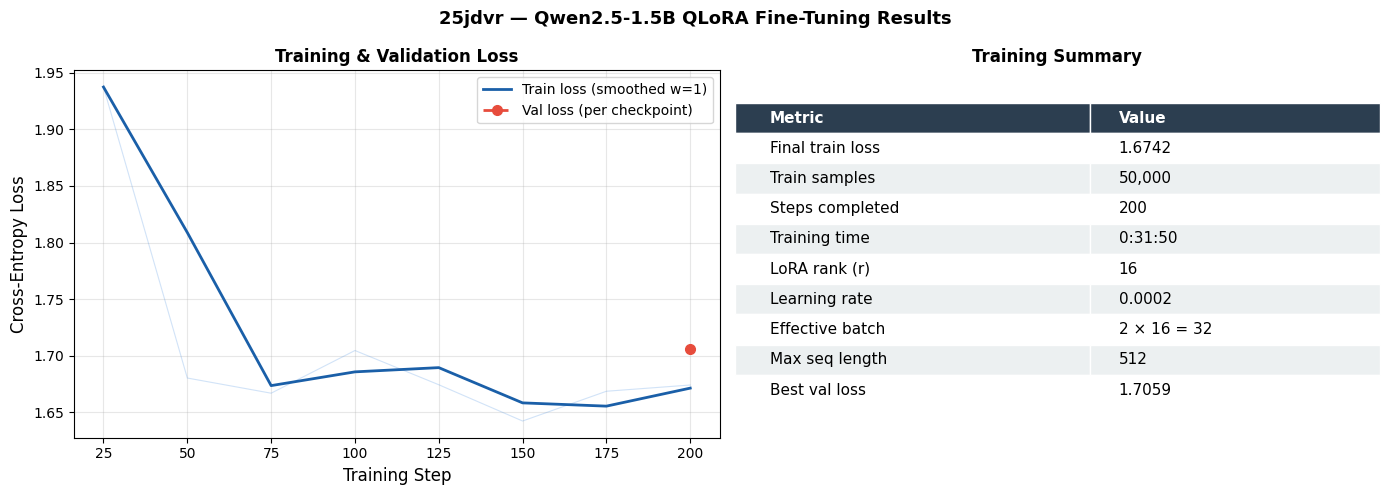

Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Loss curve saved → /content/loss_curve.png
   Download from Colab Files panel → add to Section 5 of report

BASE MODEL vs FINE-TUNED — Required for Section 5 of report
Copy the output below into your report comparison table


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



═════════════════════════════════════════════════════════════════
❓ QUESTION: How do I reverse a list in Python?

🔷 BASE MODEL (before fine-tuning):
   In Python, you can easily reverse a list using several methods. Here are some common ways to achieve this:

### Method 1: Using the `reverse()` method (Python 3.x)
The built-in `list` class has a `reverse()` method that directly reverses the order of elements.

```python
# Example list
my_list = [1, 2, 3, 4, 5]

# Reverse the list
my_list.reverse()

print(my_list)  # Output: [5, 4, 3, 2, 1]
```

### Method 2: Using slicing (Python 3.x and earlier versions)
If you're using an older version of Python where there is no direct `reverse()` method, you can use slicing.

```python
# Example list
my_list = [1, 2, 3, 4, 5]

# Reverse the list by slicing from end to start
my_list[:] = my_list[::-1]

print(my_list)  # Output: [5, 4, 3, 2, 1]
```

### Method 3: Using a loop for reversing (for loops)
For lists of small size or

✅ FINE-TUNED MODEL (

Both `max_new_tokens` (=250) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



═════════════════════════════════════════════════════════════════
❓ QUESTION: What is the difference between == and 'is' in Python?

🔷 BASE MODEL (before fine-tuning):
   In Python, `==` is used to compare values for equality (i.e., they have the same value), while `'is'` checks if two variables refer to the same object in memory.

### Key Differences:

1. **Equality vs. Identity:**
   - `==` compares the values of objects.
   - `'is'` compares whether two references point to the same object.

2. **Example 1: Comparing Values**:
   ```python
   x = [1, 2]
   y = [1, 2]

   # Check if both x and y contain the same elements
   print(x == y)  # True

   # Check if x and y are equal (same reference)
   print(id(x) == id(y))  # False
   ```

3. **Example 2: Checking References**:
   ```python
   x = [1, 2]
   y = list(range(2))

   # Check if both x and y are different lists
   print(x != y)  # True

   # Check if x and y are pointing to the same object (identity comparison)
   print(id(x)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# plot the training loss so we have something to put in the report
train_logs = [l for l in trainer.state.log_history
              if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in trainer.state.log_history if "eval_loss" in l]

if train_logs:
    steps      = [l["step"] for l in train_logs]
    train_loss = [l["loss"] for l in train_logs]

    # smooth the raw loss with a moving average so the trend is easier to read
    w = max(1, len(train_loss) // 30)
    smoothed = [
        sum(train_loss[max(0,i-w):i+1]) / len(train_loss[max(0,i-w):i+1])
        for i in range(len(train_loss))
    ]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("25jdvr — Qwen2.5-1.5B QLoRA Fine-Tuning Results",
                 fontsize=13, fontweight="bold")

    ax1.plot(steps, train_loss, alpha=0.25, color="#4A90E2", linewidth=0.8)
    ax1.plot(steps, smoothed,   color="#1A5FA8", linewidth=2,
             label=f"Train loss (smoothed w={w})")
    if eval_logs:
        ax1.plot([l["step"] for l in eval_logs],
                 [l["eval_loss"] for l in eval_logs],
                 "o--", color="#E74C3C", linewidth=2,
                 markersize=7, label="Val loss (per checkpoint)")
    ax1.set_xlabel("Training Step", fontsize=12)
    ax1.set_ylabel("Cross-Entropy Loss", fontsize=12)
    ax1.set_title("Training & Validation Loss", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)

    ax2.axis("off")
    rows = [
        ["Metric", "Value"],
        ["Final train loss", f"{train_logs[-1]['loss']:.4f}"],
        ["Train samples",    f"{len(train_dataset):,}"],
        ["Steps completed",  f"{result.global_step:,}"],
        ["Training time",    str(duration).split('.')[0]],
        ["LoRA rank (r)",    str(LORA_RANK)],
        ["Learning rate",    str(LEARNING_RATE)],
        ["Effective batch",  f"{BATCH_SIZE} × {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}"],
        ["Max seq length",   str(MAX_SEQ_LENGTH)],
    ]
    if eval_logs:
        rows.append(["Best val loss", f"{min(l['eval_loss'] for l in eval_logs):.4f}"])

    table = ax2.table(cellText=rows, cellLoc="left", loc="center",
                      colWidths=[0.55, 0.45])
    table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1, 1.9)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor("white")
        if r == 0:
            cell.set_facecolor("#2C3E50"); cell.set_text_props(color="white", fontweight="bold")
        elif r % 2 == 0:
            cell.set_facecolor("#ECF0F1")
    ax2.set_title("Training Summary", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.savefig("/workspace/loss_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Loss curve saved to /workspace/loss_curve.png")
print("  -> this maps to ~/fine-tuning/loss_curve.png on your host machine")
else:
    print("⚠️  No training logs — did training finish?")

# now compare base vs fine-tuned on the same questions — this goes in the report
print("\n" + "=" * 65)
print("BASE MODEL vs FINE-TUNED — add this to Section 5 of the report")
print("=" * 65)

FastLanguageModel.for_inference(model)

for q in BASE_TEST_PROMPTS:
    ft_resp = _generate(model, tokenizer, q)
    print(f"\n{'═'*65}")
    print(f"❓ QUESTION: {q}")
    print(f"\n🔷 BASE MODEL:")
    print(f"   {base_responses.get(q, '[not captured]')}")
    print(f"\n✅ FINE-TUNED:")
    print(f"   {ft_resp}")

print(f"\n{'='*65}")
print("✅ Report checklist:")
print("  → loss_curve.png downloaded from Colab Files")
print("  → base model responses captured above (🔷)")
print("  → fine-tuned responses captured above (✅)")


---
## Section 8 -- Test the Fine-Tuned Model

Run 3 Python questions through the model to confirm it's working before saving.

In [ ]:
# switch to inference mode and run a few test questions
# this is just to eyeball the quality before saving — not a formal evaluation
FastLanguageModel.for_inference(model)

def ask(question: str, max_new_tokens: int = 300) -> str:
    prompt = (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{question}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens  = max_new_tokens,
            temperature     = 0.7,
            top_p           = 0.9,
            do_sample       = True,
            pad_token_id    = tokenizer.eos_token_id,
        )
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


test_questions = [
    "How do I read a CSV file in Python using pandas?",
    "What is the difference between a list and a tuple in Python?",
    "How do I handle exceptions in Python with try/except? Give an example.",
]

for i, q in enumerate(test_questions, 1):
    print(f"\n{'='*60}")
    print(f"Test {i}: {q}")
    print(f"{'='*60}")
    print(ask(q))

print("\n✅ Test complete — review the answers above before saving")


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Test 1: How do I read a CSV file in Python using pandas?


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The following line of code is causing your problem:

 df = pd.read_csv(csvFile)
 

 The error you get means that the csv file does not contain any data.

 You can verify this by looking at its size in bytes (you might want to use an online tool for this):

 $ du -sh *.csv
23M test.csv
$ cat test.csv | wc -c
18560
 

 If there are no lines in it then either the file was not created or was deleted after running the script.

 As @Joris suggested, try replacing

 import os.path as op
with open(op.dirname(csvFile) + '/test.csv') as f:
 df = pd.read_csv(f, index_col='Unnamed: 0', dtype=float)

 

 This will look for the 'test.csv' file relative to the location of your script and if it cannot be found then it will default to the directory containing the script itself.

Test 2: What is the difference between a list and a tuple in Python?


Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The main difference is that tuples are immutable , meaning they can't be changed after creation.

 In contrast to lists, which contain references to objects (i.e., values), tuples have their own instances of objects - so you cannot change the value within them later on either:

 >>> t = ('hello', 42)
>>> print(t[1])
42

>>> t[1] = 'world'
Traceback (most recent call last):
 File "<stdin>", line 1, in <module>
TypeError: 'tuple' object does not support item assignment
 

 This means that when you create a tuple it's created as an actual object instance in memory, rather than simply holding a reference to some other object.

 For more information see here .

Test 3: How do I handle exceptions in Python with try/except? Give an example.
It's not necessary to call the except statement at all. You can catch and ignore any exceptions that occur.

 In fact, if you want to do something about an exception, you probably should never use it:

 def my_function():
 # some code here

 try:
 pass
 ex

In [ ]:
# try your own question here
my_question = "How do I sort a list of dictionaries by a specific key in Python?"

print(f"Q: {my_question}\n")
print(ask(my_question, max_new_tokens=400))


Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: How do I sort a list of dictionaries by a specific key in Python?

The built-in sorted() function will let you sort your list using any other iterable as the first argument:

 >>> sorted(myList, key=lambda x: x['name'])
[{'id': 2130768540}, {'id': 298163683}]
 

 It's worth noting that the sorting is done in-place and doesn't return anything (it mutates myList , not a copy).

 If you're interested in more advanced sorting algorithms, take a look at Tim Peters' introduction to the algorithm .

 Edit: Just for fun, here's an alternative implementation based on @RanG 's suggestion.

 def sortByKey(arr,key):
 # Sort only one level deep into a nested dict.
 for k,v in arr:
 if isinstance(v,dict):
 v = sortByKey(v,k)
 # Return a new version of arr containing just what we want.
 return [v] + arr[len(v):]
 

 Usage example:

 >>> from operator import itemgetter
>>> myDict = [{'id': 2130768540,'name':'Test'},{'id': 298163683,'name':'Another Name'}]
>>> sorted(myDict, key=itemgetter('name'))


---
## Section 9 -- Save Model

Three outputs:
1. **LoRA adapter** -- saved locally + uploaded to S3 (`model/finetuned-qwen/adapter/`)
2. **GGUF file** -- exported for Ollama + uploaded to S3 (`model/finetuned-qwen/gguf/`)
3. **Modelfile** -- Ollama config file + uploaded to S3


In [ ]:
# save the LoRA adapter weights locally then push them to S3
# this is just the small adapter (~60 MB), not the full model —
# useful as a backup and for anyone who wants to reload it later
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)
model.save_pretrained(LOCAL_MODEL_DIR)
tokenizer.save_pretrained(LOCAL_MODEL_DIR)
print(f"✅ LoRA adapter saved to {LOCAL_MODEL_DIR}")

s3 = boto3.client("s3")
for fname in os.listdir(LOCAL_MODEL_DIR):
    local_file = os.path.join(LOCAL_MODEL_DIR, fname)
    if not os.path.isfile(local_file):
        continue
    s3_key = f"model/finetuned-qwen/adapter/{fname}"
    s3.upload_file(local_file, S3_BUCKET, s3_key)
    print(f"  Uploaded: s3://{S3_BUCKET}/{s3_key}")

print("\n✅ Adapter uploaded to S3")


Unsloth: Restored added_tokens_decoder metadata in /content/finetuned-model/tokenizer_config.json.


? LoRA adapter saved to /content/finetuned-model
  Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/adapter/chat_template.jinja
  Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/adapter/adapter_config.json
  Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/adapter/adapter_model.safetensors
  Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/adapter/tokenizer.json
  Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/adapter/tokenizer_config.json
  Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/adapter/README.md

? Adapter uploaded to S3


---
## Section 9b — Convert to GGUF & Upload to S3 (llama.cpp)

Downloads the merged HuggingFace model from S3, converts it to GGUF format
using `llama.cpp`'s `convert_hf_to_gguf.py`, creates the Ollama Modelfile,
and uploads both to S3 ready for EC2 deployment.

**WHY llama.cpp here:** The Unsloth GGUF export above uses Unsloth's internal
quantizer. This approach uses llama.cpp directly — the same tool Ollama uses
internally — which guarantees full compatibility with any Ollama version on EC2.

In [ ]:
# start fresh so there's no leftover files from a previous run
!rm -rf /workspace/finetuned-qwen-hf
!mkdir -p /workspace/finetuned-qwen-hf

# pull the merged HuggingFace model we saved to S3 earlier
# this is the full model (base + LoRA weights merged), not just the adapter
!aws s3 sync \
  s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/ \
  /workspace/finetuned-qwen-hf/ \
  --region us-east-1

# quick check that the files actually landed
!ls -lh /workspace/finetuned-qwen-hf/

download: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/Modelfile to finetuned-qwen-hf/Modelfile
download: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/config.json to finetuned-qwen-hf/config.json
download: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/chat_template.jinja to finetuned-qwen-hf/chat_template.jinja
download: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/tokenizer_config.json to finetuned-qwen-hf/tokenizer_config.json
download: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/tokenizer.json to finetuned-qwen-hf/tokenizer.json
download: s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/model.safetensors to finetuned-qwen-hf/model.safetensors
total 2.9G
-rw-r--r-- 1 root root 2.5K May  1 09:30 chat_template.jinja
-rw-r--r-- 1 root root 1.6K May  1 09:31 config.json
-rw-r--r-- 1 root root  249 May  1 09:31 Modelfile
-rw-r--r-- 1 root root 2.9G May  1 09:30 model.safetensors
-rw-r--r-- 1 root root 7.1K May  1 09:31 tokenizer_config.json
-rw-

In [ ]:
# grab llama.cpp — we only need the latest commit, so --depth 1 keeps it fast
# this gives us the convert_hf_to_gguf.py script we need in the next cell
!rm -rf /workspace/llama.cpp
!git clone --depth 1 https://github.com/ggml-org/llama.cpp /workspace/llama.cpp

Cloning into '/content/llama.cpp'...
remote: Enumerating objects: 3008, done.
remote: Counting objects: 100% (3008/3008), done.
remote: Compressing objects: 100% (2377/2377), done.
remote: Total 3008 (delta 617), reused 2310 (delta 555), pack-reused 0 (from 0)
Receiving objects: 100% (3008/3008), 32.35 MiB | 20.20 MiB/s, done.
Resolving deltas: 100% (617/617), done.


In [ ]:
# install the Python packages llama.cpp needs for the conversion
# mostly numpy and sentencepiece — nothing heavy
!pip install -r /workspace/llama.cpp/requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu, https://download.pytorch.org/whl/nightly, https://download.pytorch.org/whl/cpu, https://download.pytorch.org/whl/nightly, https://download.pytorch.org/whl/cpu, https://download.pytorch.org/whl/nightly
Ignoring torch: markers 'platform_machine == "s390x"' don't match your environment
Ignoring torch: markers 'platform_machine == "s390x"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 107.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# convert the HuggingFace model to GGUF format
# GGUF is the file format Ollama expects — without this step the EC2 server can't load the model
# --outtype f16 keeps full float16 precision; we quantize to q4_k_m in the next step on EC2
!python /workspace/llama.cpp/convert_hf_to_gguf.py \
  /workspace/finetuned-qwen-hf \
  --outfile /workspace/model.gguf \
  --outtype f16

INFO:hf-to-gguf:Loading model: finetuned-qwen-hf
INFO:numexpr.utils:NumExpr defaulting to 2 threads.
INFO:hf-to-gguf:Model architecture: Qwen2ForCausalLM
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors'
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:token_embd.weight,         torch.bfloat16 --> F16, shape = {1536, 151936}
INFO:hf-to-gguf:blk.0.attn_norm.weight,    torch.bfloat16 --> F32, shape = {1536}
INFO:hf-to-gguf:blk.0.ffn_down.weight,     torch.bfloat16 --> F16, shape = {8960, 1536}
INFO:hf-to-gguf:blk.0.ffn_gate.weight,     torch.bfloat16 --> F16, shape = {1536, 8960}
INFO:hf-to-gguf:blk.0.ffn_up.weight,       torch.bfloat16 --> F16, shape = {1536, 8960}
INFO:hf-to-gguf:blk.0.ffn_norm.weight,     torch.bfloat16 --> F32, shape = {1536}
INFO:hf-to-gguf:blk.0.attn_k.bias,         torch.bfloat16 --> F32, shape = {256}
INFO:hf-to-gguf:blk.0.attn_k.weight,       torch.bfloat16 --> F16, shape = {1536,

In [ ]:
%%writefile /workspace/Modelfile
FROM ./model.gguf

SYSTEM """
You are a helpful Python programming assistant. Provide clear, accurate answers with working code examples.
"""

# these control how the model generates text
# temperature 0.7 = balanced between creative and focused answers
# num_ctx 2048 = how many tokens the model can see at once (keeps memory usage low on EC2)
PARAMETER temperature 0.7
PARAMETER top_p 0.9
PARAMETER top_k 40
PARAMETER repeat_penalty 1.1
PARAMETER num_ctx 2048

Writing /content/Modelfile


In [ ]:
# push both files to S3 so the EC2 instance can pull them
# model.gguf is the actual model weights (~3GB)
# Modelfile tells Ollama how to load and configure it
!aws s3 cp /workspace/model.gguf \
  s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/model.gguf \
  --region us-east-1

!aws s3 cp /workspace/Modelfile \
  s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/Modelfile \
  --region us-east-1

upload: ./model.gguf to s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/model.gguf
upload: ./Modelfile to s3://25jdvr-chatbot-bucket/model/finetuned-qwen/gguf/Modelfile
